# 🚗 Car Breakdown Prediction - Machine Learning Assignment

## 📋 Project Overview
**Doel**: Voorspel of een voertuig binnen 30 dagen een mechanische storing zal hebben.

**Bron**: [Kaggle Competition](https://www.kaggle.com/competitions/car-breakdown-prediction)

**Data Locatie**: `src/train_CarBreakDown.csv` en `src/test_CarBreakDown.csv`

## 🎯 Taak
Gegeven 13 features over een auto (brand, leeftijd, kilometers, onderhoud, etc.), classificeer:
- **0** → ✅ Geen storing verwacht in volgende 30 dagen
- **1** → ⚠️ Storing verwacht binnen volgende 30 dagen

## 📊 Verwacht Output Format
```
id,breakdown_next_30_days
1356,1
889,1
```

## STAP 1️⃣: Imports & Data Paths
Laad all required libraries en definieer file paths

In [13]:
# ============================================
# IMPORTS: Benodigde bibliotheken voor data processing en machine learning
# ============================================
# Pandas: data manipulatie en dataframe operaties
# NumPy: numerieke berekeningen
# Scikit-learn: train/test split, classificatie-metriek en cross-validatie
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt

# ============================================
# FILE PATHS: Locatie van de trainings- en testgegevens
# ============================================
# Train dataset: bevat features + target label (breakdown_next_30_days)
# Test dataset: bevat alleen features; predictions moeten gedaan worden
file = "./src/train_CarBreakDown.csv"
test_file = "./src/test_CarBreakDown.csv"

## STAP 2️⃣: Data Inladen
Functie om CSV bestanden in te lezen

In [14]:
# ============================================
# DATA INLEZEN FUNCTIE
# ============================================
# Leest een CSV-bestand met auto-gegevens in
# 
# Parameters:
#   file (str): Pad naar het CSV-bestand
# 
# Returns:
#   pd.DataFrame: Dataframe met alle rijen en kolommen uit het CSV-bestand
# 
# Details:
#   - Encoding: UTF-8 (ondersteunt speciale tekens)
#   - Delimiter: komma (standaard CSV formaat)
def get_car_breakdown_data(file: str):
    return pd.read_csv(file, encoding="UTF-8", sep=",")

In [15]:
# test read the data
dirty_data = get_car_breakdown_data(file)
print(dirty_data)

        id vehicle_brand  vehicle_age_years     mileage_km  engine_hours  \
0      959        Toyota               20.0  494744.972722   9700.481467   
1      804        Toyota                0.0   38376.684834   1650.726428   
2     1304       Hyundai                1.0  188558.432414   6678.958321   
3      268        Toyota                5.0   92828.113285   2986.923461   
4       47           NaN               10.0  118366.394287   4222.193011   
...    ...           ...                ...            ...           ...   
1045   562       Renault                6.0  131602.464358   4586.327861   
1046   993        Toyota                9.0  127224.810750   4106.036923   
1047   245          Ford               19.0   74204.367905   2323.811128   
1048   883           BMW               10.0  198492.993706   6643.176908   
1049   690          Ford                4.0  344673.426523   9831.330944   

      last_service_km_ago  oil_quality_pct  avg_trip_length_km  \
0             1672.04

In [16]:
print("Dataset shape", dirty_data.shape)

Dataset shape (1050, 14)


In [17]:
dirty_data.head()

,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
4,47,NaN,10.0,118366.394287,4222.193011,12551.181627,65.766074,47.159242,low,diesel,77.368891,6.724967,winter,0


## STAP 3️⃣: Data Cleaning & Feature Engineering
Verwijder outliers, behandel ontbrekende waarden, engineer nieuwe features

In [18]:
# ============================================
# STAP 1: DATA CLEANING EN PREPROCESING
# ============================================
# Deze stap verwijdert ruis en fouten uit de gegevens

# Zet lege strings om naar NaN (ontbrekende waarden)
df = dirty_data.replace(r"^\s*$", np.nan, regex=True)

# --- Outliers detecteren en corrigeren ---
# Mileage: realistische auto's hebben max ~2 miljoen km
df.loc[df['mileage_km'] > 2000000, 'mileage_km'] = np.nan
# Engine hours: kunnen niet negatief zijn
df.loc[df['engine_hours'] < 0, 'engine_hours'] = np.nan
# Cleanliness: score zou niet boven 100% kunnen zijn
df.loc[df['cleanliness_score'] > 100, 'cleanliness_score'] = np.nan
# Driver satisfaction: schaal is 0-10
df.loc[df['driver_satisfaction_score'] > 10, 'driver_satisfaction_score'] = np.nan

# ============================================
# STAP 2: FEATURES EN TARGET SCHEIDEN
# ============================================
# X bevat alle features (input voor model)
# Y bevat target label (wat we willen voorspellen: breakdown_next_30_days)
X = df.drop(columns=["id", "breakdown_next_30_days"])
Y = df["breakdown_next_30_days"]

# Identificeer numerieke en categorische kolommen
num_cols = X.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# ============================================
# STAP 3: ONTBREKENDE WAARDEN BEHANDELING
# ============================================
# Voor tree-based modellen: missing indicators helpen veel!
# Dit creeërt een extra boolean kolom per feature die aangeeft of waarde ontbrak
for col in num_cols:
    X[col + "_missing"] = X[col].isna().astype(int)

# Vul numerieke kolommen in met mediaan waarde (robuust tegen outliers)
# Mediaan wordt ALLEEN berekend op trainingdata - kritiek voor juiste validatie!
medians = X[num_cols].median()
X[num_cols] = X[num_cols].fillna(medians)

# Vul categorische kolommen in met placeholder-waarde
X[cat_cols] = X[cat_cols].fillna("missing")

# ============================================
# STAP 4: FEATURE ENGINEERING (handmatige feature creatie)
# ============================================
# Deze features worden afgeleid van bestaande features
# Ze geven model meer informatie over auto-intensitief gebruik

# Hoe veel km per jaar? (meting van gebruiksintensiteit) 1e-5 toegevoegd om deling door nul te voorkomen    
X['mileage_per_year'] = X['mileage_km'] / (X['vehicle_age_years'] + 1e-5)
# Hoe efficient is de motor? (lager = efficiënter)
X['engine_hours_per_km'] = X['engine_hours'] / (X['mileage_km'] + 1e-5)
# Wat deel van mileage sinds vorige service? (belangrijk voor slijtage)
X['last_service_ratio'] = X['last_service_km_ago'] / (X['mileage_km'] + 1e-5)

# ============================================
# STAP 5: ENCODING VAN CATEGORISCHE FEATURES
# ============================================
# One-hot encoding: transformeert categorische waarden naar binaire (0/1) kolommen
# drop_first=True: voorkómt multicollineariteit (dummy variable trap)
# dtype=int: garandeert integer types (efficiënter dan booleans)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

C:\Users\lenne\AppData\Local\Temp\ipykernel_20304\1653484799.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


## STAP 4️⃣: Train/Test Split
Verdeel dataset in 70% training en 30% testing met stratificatie

In [19]:
# ============================================
# STAP 6: TRAIN/TEST SPLIT
# ============================================
# Verdeel dataset in trainings- en testset
# 
# Parameters uitgelegd:
#   - test_size=0.3: 30% data voor testing, 70% voor training
#   - random_state=100: seed voor reproduceerbaarheid (dezelfde split telkens)
#   - stratify=Y: zorg dat train/test dezelfde break-down ratio hebben
#                 (belangrijk voor imbalanced datasets!)
#
# Resultaat:
#   - X_train: features voor training (735 samples)
#   - X_test: features voor testen (315 samples)
#   - y_train: target labels voor training
#   - y_test: target labels voor testing (gebruikt voor evaluatie)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=100,
    stratify=Y
)

## STAP 5️⃣: Random Forest Model Training
Train ensemble model met imbalance-handling via class_weight

In [20]:
# ============================================
# STAP 7: RANDOM FOREST MODEL TRAINING
# ============================================
# Random Forest is een ensemble-methode dat meerdere bomen combineert voor betere voorspellingen

# --- IMBALANCE HANDLING ---
# Dataset probleem: veel meer "geen breakdown" (0) dan "wel breakdown" (1)
# Oplossing: class_weight='balanced' geeft meer gewicht aan minderheidsklasse
clf_rf = RandomForestClassifier(
    n_estimators=100,          # Aantal bomen in forest
    random_state=1,            # Reproduceerbare resultaten
    class_weight='balanced',   # Handel imbalance af
    n_jobs=1                  # Gebruik alle CPU cores
)

# --- TRAINEN ---
# Fit model op trainings data
clf_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## STAP 6️⃣: Model Evaluatie
Bereken accuracy, precision, recall, F1-score en cross-validatie

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       175
           1       0.00      0.00      0.00        35

    accuracy                           0.83       210
   macro avg       0.42      0.50      0.45       210
weighted avg       0.69      0.83      0.76       210



c:\dev\PE_Assignment_AI_TM\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\dev\PE_Assignment_AI_TM\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\dev\PE_Assignment_AI_TM\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


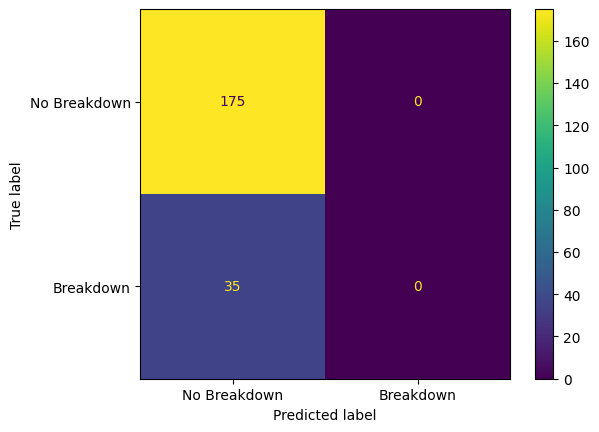

CV accuracy: 0.8314285714285715


In [21]:
# ============================================
# STAP 8: MODEL EVALUATIE
# ============================================

# --- Test set performance ---
# Hoeveel voorspellingen zijn correct?
accuracy = clf_rf.score(X_test, y_test)
print("Accuracy:", accuracy)

# --- Gedetailleerde metriek ---
print(classification_report(y_test, clf_rf.predict(X_test)))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, clf_rf.predict(X_test))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Breakdown", "Breakdown"]).plot()
plt.show()

# --- Cross-validatie (meer robuust) ---
scores = cross_val_score(clf_rf, X, Y, cv=5)
print("CV accuracy:", scores.mean())

## STAP 6.5️⃣: Hyperparameter Tuning
Tune Random Forest parameters to improve accuracy.

In [ ]:
# Tune Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=1), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best params for Random Forest:", grid_rf.best_params_)
print("Best CV score for Random Forest:", grid_rf.best_score_)

# Train best RF
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print("Test accuracy for tuned Random Forest:", metrics.accuracy_score(y_test, y_pred_best_rf))

# Compare
print("\nComparison:")
print("Original RF accuracy:", metrics.accuracy_score(y_test, clf_rf.predict(X_test)))
print("Tuned RF accuracy:", metrics.accuracy_score(y_test, y_pred_best_rf))

## STAP 7️⃣: Test Data Verwerken & Predictions Maken
Pas EXACT dezelfde preprocessing toe op testdata en genereer submission file

In [ ]:
# ============================================
# STAP 9: TESTDATA VERWERKEN EN VOORSPELLLINGEN MAKEN
# ============================================

# Lees testdata in (geen target labels!)
test_df = pd.read_csv(test_file)

# Sla IDs op (nodig voor submission file)
test_ids = test_df["id"]

# ============================================
# KRITIEK: Testdata EXACT HETZELFDE verwerken als traindata!
# ============================================
# Dit zorgt ervoor dat model dezelfde inputs krijgt

test_X = test_df.drop(columns=["id"]).copy()

# 1. Zet lege strings om naar NaN (identiek aan trainings-cleaning)
test_X = test_X.replace(r"^\s*$", np.nan, regex=True)

# 2. Maak missing indicators (identiek aan trainings-preprocessing)
for col in num_cols:
    test_X[col + "_missing"] = test_X[col].isna().astype(int)

# 3. Vul numerieke waarden in met TRAININGS-mediaan!
#    Mag NIET de test-mediaan gebruiken, anders leaks trainings-info
test_X[num_cols] = test_X[num_cols].fillna(medians)

# 4. Vul categorische waarden in
test_X[cat_cols] = test_X[cat_cols].fillna("missing")

# ============================================
# STAP 10: FEATURE ENGINEERING (identiek aan traindata)
# ============================================
# Dezelfde engineered features als trainings-set
test_X['mileage_per_year'] = test_X['mileage_km'] / (test_X['vehicle_age_years'] + 1e-5)
test_X['engine_hours_per_km'] = test_X['engine_hours'] / (test_X['mileage_km'] + 1e-5)
test_X['last_service_ratio'] = test_X['last_service_km_ago'] / (test_X['mileage_km'] + 1e-5)

# 5. One-hot encoding (identiek aan traindata)
test_X = pd.get_dummies(test_X, columns=cat_cols, drop_first=True, dtype=int)

# ============================================
# KRITIEK: Herindexeer naar TRAININGS-kolommen
# ============================================
# Voeg eventueel ontbrekende kolommen toe, zet gedropt kolommen op 0
# Dit zorgt ervoor dat model dezelfde features input krijgt als bij training!
test_X = test_X.reindex(columns=X.columns, fill_value=0)

# ============================================
# STAP 11: VOORSPELLEN EN SUBMISSION
# ============================================
# Maak voorspellingen met trainede model
predictions = best_rf.predict(test_X)

# Maak output dataframe in juist format
# Kolom 1: auto ID
# Kolom 2: binaire voorspelling (0 = geen breakdown verwacht, 1 = wel)
output = pd.DataFrame({
    "id": test_ids.astype(int),
    "breakdown_next_30_days": predictions.astype(int)
})

# Schrijf naar CSV file (kan naar Kaggle geupload worden)
output.to_csv("submission.csv", mode='w', index=False)
print("Submission file created: submission.csv")

Submission file created: submission.csv


## STAP 8️⃣: Feature Importance Analyse
Analyse welke features het model gebruikt om voorspellingen te maken

In [ ]:
# ============================================
# STAP 12: FEATURE IMPORTANCE ANALYSE
# ============================================
# Welke features zijn het meest belangrijk voor het model?
# Dit helpt begrijpen wat signalen voor breakdown voorspellen

# Extract importance scores uit model
importances = pd.Series(clf_rf.feature_importances_, index=X.columns)

# Sorteer van belangrijkste naar minst belangrijk
print("=== FEATURE IMPORTANCE (Top 10) ===")
print(importances.sort_values(ascending=False).head(10))
print("\n=== ALLE FEATURES ===")
print(importances)

=== FEATURE IMPORTANCE (Top 10) ===
oil_quality_pct              0.087753
mileage_per_year             0.083057
engine_hours_per_km          0.078311
cleanliness_score            0.075326
avg_trip_length_km           0.074329
engine_hours                 0.074263
driver_satisfaction_score    0.072985
mileage_km                   0.071894
last_service_km_ago          0.071027
vehicle_age_years            0.070874
dtype: float64

=== ALLE FEATURES ===
vehicle_age_years                    0.070874
mileage_km                           0.071894
engine_hours                         0.074263
last_service_km_ago                  0.071027
oil_quality_pct                      0.087753
avg_trip_length_km                   0.074329
cleanliness_score                    0.075326
driver_satisfaction_score            0.072985
vehicle_age_years_missing            0.000773
mileage_km_missing                   0.004813
engine_hours_missing                 0.001411
last_service_km_ago_missing          0.0